# Synthetic DS2 generator

This notebook creates public stand-ins for the proprietary D2 data used in Paper II:

*Øien, Christian Dalheim; Myhr, Ole Runar; Ringen, Geir. Towards hybrid
modelling of aluminium extrusion mechanical properties – A univariate
representation of artificial aging. Materials Research Proceedings 54 (2025),
819–828.
DOI: https://doi.org/10.21741/9781644903599-88*

Synthetic data generation is done by:
- generating `N_ALLOYS` alloys
- generating `TOTAL_CYCLES` aging cycles
- selecting `CYCLES_PER_ALLOY` cycles per alloy spanning most of the underaged–overaged range
- making one row per `(alloy, selected cycle)` pair

The cycle catalogue uses rounded **5 °C** temperature steps and **60 s** duration steps.

The Scheil integral is computed by:
- defining the temperature anchors `T6`–`T10` at the corresponding cumulative times
- linearly interpolating a second-resolved temperature history
- converting each second to an equivalent isothermal time `t*`
- summing `dI = 1 / t*` over the full profile


In [1]:
from pathlib import Path
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_SEED = 20260423
N_ALLOYS = 46
TOTAL_CYCLES = 124
CYCLES_PER_ALLOY = 65

OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(exist_ok=True)

DS2_FULL_FILE = OUTPUT_DIR / "DS2_full.xlsx"
DS2_SCHEIL_FILE = OUTPUT_DIR / "DS2_scheil.xlsx"

CHEMISTRY_COLS = [
    "Mg [wt.%]", "Si [wt.%]", "Fe [wt.%]", "Mn [wt.%]", "Cu [wt.%]", "Cr [wt.%]",
]
AGING_SEGMENT_COLS = ["T6", "T7", "T8", "T9", "T10", "t6_7", "t7_8", "t8_9", "t9_10"]
SCHEIL_COL = "Scheil"
TARGET_COLS = ["Rp0.2 [Mpa]", "Rm [MPa]"]

DS2_FULL_COLS = CHEMISTRY_COLS + AGING_SEGMENT_COLS + [SCHEIL_COL] + TARGET_COLS
DS2_SCHEIL_COLS = CHEMISTRY_COLS + [SCHEIL_COL] + TARGET_COLS


In [2]:
# Scheil settings used for the synthetic aging-cycle generation.
Q_D = 130_000.0
R_GAS = 8.314
T_REF_K = 185.0 + 273.0
T_REF_SECONDS = 5.0 * 3600.0


def equivalent_isothermal_time_seconds(temp_c):
    temp_k = np.asarray(temp_c, dtype=float) + 273.0
    return T_REF_SECONDS * np.exp((Q_D / R_GAS) * ((1.0 / temp_k) - (1.0 / T_REF_K)))


def scheil_integral_from_row(row, return_profile=False):
    '''
    Compute the Scheil integral from the temperature anchors T6–T10 and the
    corresponding durations t6_7–t9_10.

    The implementation:
    1) places the temperature anchors at their cumulative times,
    2) linearly interpolates the second-resolved temperature profile,
    3) evaluates t* for each second,
    4) accumulates dI = 1 / t*.

    If return_profile=True, the full second-resolved profile is returned as a
    dataframe for inspection.
    '''
    p0 = 0
    p1 = int(row["t6_7"])
    p2 = int(row["t6_7"] + row["t7_8"])
    p3 = int(row["t6_7"] + row["t7_8"] + row["t8_9"] + 1)
    p4 = int(row["t6_7"] + row["t7_8"] + row["t8_9"] + row["t9_10"] + 1)

    anchors = [p0, p1, p2, p3, p4]
    temps_c = [float(row["T6"]), float(row["T7"]), float(row["T8"]), float(row["T9"]), float(row["T10"])]

    pieces = []
    for seg_idx in range(4):
        x0, x1 = anchors[seg_idx], anchors[seg_idx + 1]
        y0, y1 = temps_c[seg_idx], temps_c[seg_idx + 1]
        segment = np.linspace(y0, y1, x1 - x0 + 1)
        if seg_idx > 0:
            segment = segment[1:]
        pieces.append(segment)

    profile_c = np.concatenate(pieces)
    profile_k = profile_c + 273.0
    t_star = T_REF_SECONDS * np.exp((Q_D / R_GAS) * ((1.0 / profile_k) - (1.0 / T_REF_K)))
    d_i = 1.0 / t_star
    i_cum = np.cumsum(d_i)

    if return_profile:
        time_s = np.arange(profile_c.size)
        return pd.DataFrame({
            "time_s": time_s,
            "time_h": time_s / 3600.0,
            "T [C]": profile_c,
            "T [K]": profile_k,
            "t* [s]": t_star,
            "dI": d_i,
            "I": i_cum,
        })

    return float(i_cum[-1])


In [3]:
def make_synthetic_chemistry(rng, alloy_idx):
    '''
    Synthetic alloy chemistry generator.
    The ranges are broad and non-proprietary, but shaped to remain plausible
    for Al-Mg-Si-like examples.
    '''
    family = alloy_idx % 4
    if family == 0:
        mg = rng.uniform(0.28, 0.48)
        si = rng.uniform(0.38, 0.62)
    elif family == 1:
        mg = rng.uniform(0.38, 0.58)
        si = rng.uniform(0.48, 0.74)
    elif family == 2:
        mg = rng.uniform(0.48, 0.72)
        si = rng.uniform(0.56, 0.86)
    else:
        mg = rng.uniform(0.58, 0.90)
        si = rng.uniform(0.66, 0.98)

    fe = np.clip(rng.normal(0.206, 0.010), 0.185, 0.240)
    mn = np.clip(0.014 + rng.beta(1.2, 6.0) * 0.48, 0.010, 0.500)
    cu = np.clip(rng.beta(0.8, 5.0) * 0.14, 0.0, 0.130)
    cr = 0.0 if rng.random() < 0.85 else np.clip(rng.uniform(0.0001, 0.0006), 0.0, 0.001)

    return {
        "Mg [wt.%]": round(float(mg), 3),
        "Si [wt.%]": round(float(si), 3),
        "Fe [wt.%]": round(float(fe), 3),
        "Mn [wt.%]": round(float(mn), 3),
        "Cu [wt.%]": round(float(cu), 3),
        "Cr [wt.%]": round(float(cr), 3),
    }


def make_type1_cycle(temp_c, hold_seconds, ramp_seconds=7200, settle_seconds=60, final_seconds=60):
    return {
        "cycle_type": "type1",
        "T6": 20,
        "T7": int(temp_c),
        "T8": int(temp_c),
        "T9": 20,
        "T10": 20,
        "t6_7": int(ramp_seconds),
        "t7_8": int(hold_seconds),
        "t8_9": int(settle_seconds),
        "t9_10": int(final_seconds),
    }


def make_type2_cycle(temp_low_c, temp_high_c, hold_low_seconds, ramp_mid_seconds, hold_high_seconds, ramp_in_seconds=600):
    return {
        "cycle_type": "type2",
        "T6": 20,
        "T7": int(temp_low_c),
        "T8": int(temp_low_c),
        "T9": int(temp_high_c),
        "T10": int(temp_high_c),
        "t6_7": int(ramp_in_seconds),
        "t7_8": int(hold_low_seconds),
        "t8_9": int(ramp_mid_seconds),
        "t9_10": int(hold_high_seconds),
    }


def cycle_key(row):
    return tuple(int(row[col]) for col in AGING_SEGMENT_COLS)


def choose_type1_temp(target_log_i, idx):
    if target_log_i <= -1.3:
        base = 150
    elif target_log_i <= -1.0:
        base = 155
    elif target_log_i <= -0.7:
        base = 160
    elif target_log_i <= -0.4:
        base = 165
    elif target_log_i <= -0.1:
        base = 170
    elif target_log_i <= 0.2:
        base = 175
    elif target_log_i <= 0.5:
        base = 180
    elif target_log_i <= 0.8:
        base = 185
    elif target_log_i <= 1.1:
        base = 190
    elif target_log_i <= 1.4:
        base = 195
    elif target_log_i <= 1.7:
        base = 200
    elif target_log_i <= 1.9:
        base = 205
    else:
        base = 210

    if -0.2 <= target_log_i <= 1.6:
        base = int(np.clip(base + [-5, 0, 5][idx % 3], 150, 210))
    return base


def choose_type2_params(target_log_i, idx):
    if target_log_i < -1.0:
        lows = [150, 155, 160]
        highs = [180, 185, 190]
        hold_lows = [60, 120, 300]
        hold_highs = [60, 120, 300]
    elif target_log_i < -0.2:
        lows = [150, 155, 160, 165]
        highs = [185, 190, 195]
        hold_lows = [120, 300, 600]
        hold_highs = [120, 300, 600]
    elif target_log_i < 0.6:
        lows = [155, 160, 165, 170]
        highs = [190, 195, 200]
        hold_lows = [300, 600, 900]
        hold_highs = [300, 600, 900]
    else:
        lows = [160, 165, 170, 175]
        highs = [195, 200, 205, 210]
        hold_lows = [600, 900, 1800]
        hold_highs = [600, 1800, 3600]

    return (
        lows[idx % len(lows)],
        highs[(idx // 2) % len(highs)],
        hold_lows[idx % len(hold_lows)],
        hold_highs[(idx // 3) % len(hold_highs)],
    )


def solve_type1_cycle(target_i, temp_c, max_hold_seconds=120 * 3600):
    lo, hi = 60, int(max_hold_seconds)

    def eval_hold(hold_seconds):
        cycle = make_type1_cycle(temp_c=temp_c, hold_seconds=hold_seconds)
        return scheil_integral_from_row(cycle)

    if target_i <= eval_hold(lo):
        hold = lo
    elif target_i >= eval_hold(hi):
        hold = hi
    else:
        while hi - lo > 60:
            mid = int(((lo + hi) // 120) * 60)
            mid = max(lo + 60, mid)
            if eval_hold(mid) < target_i:
                lo = mid
            else:
                hi = mid
        candidate_holds = range(max(60, lo - 300), min(int(max_hold_seconds), hi + 300) + 1, 60)
        hold = min(candidate_holds, key=lambda h: abs(eval_hold(h) - target_i))

    cycle = make_type1_cycle(temp_c=temp_c, hold_seconds=int(hold))
    cycle["Scheil"] = scheil_integral_from_row(cycle)
    return cycle


def solve_type2_cycle(target_i, temp_low_c, temp_high_c, hold_low_seconds, hold_high_seconds, max_ramp_mid_seconds=96 * 3600):
    lo, hi = 60, int(max_ramp_mid_seconds)

    def eval_ramp(ramp_mid_seconds):
        cycle = make_type2_cycle(
            temp_low_c=temp_low_c,
            temp_high_c=temp_high_c,
            hold_low_seconds=hold_low_seconds,
            ramp_mid_seconds=ramp_mid_seconds,
            hold_high_seconds=hold_high_seconds,
        )
        return scheil_integral_from_row(cycle)

    if target_i <= eval_ramp(lo):
        ramp_mid = lo
    elif target_i >= eval_ramp(hi):
        ramp_mid = hi
    else:
        while hi - lo > 60:
            mid = int(((lo + hi) // 120) * 60)
            mid = max(lo + 60, mid)
            if eval_ramp(mid) < target_i:
                lo = mid
            else:
                hi = mid
        candidate_ramps = range(max(60, lo - 300), min(int(max_ramp_mid_seconds), hi + 300) + 1, 60)
        ramp_mid = min(candidate_ramps, key=lambda r: abs(eval_ramp(r) - target_i))

    cycle = make_type2_cycle(
        temp_low_c=temp_low_c,
        temp_high_c=temp_high_c,
        hold_low_seconds=hold_low_seconds,
        ramp_mid_seconds=int(ramp_mid),
        hold_high_seconds=hold_high_seconds,
    )
    cycle["Scheil"] = scheil_integral_from_row(cycle)
    return cycle


def build_cycle_catalog(total_cycles=TOTAL_CYCLES):
    '''
    Build the full synthetic cycle catalogue first, before any alloy rows are made.
    The catalogue intentionally spans roughly I = 1e-2 to I = 1e2.
    '''
    n_type1 = total_cycles // 2
    n_type2 = total_cycles - n_type1
    cycles = []
    seen = set()

    for i, target_i in enumerate(np.logspace(-2, 2, n_type1)):
        target_log_i = np.log10(target_i)
        temp_c = choose_type1_temp(target_log_i, i)
        cycle = solve_type1_cycle(target_i=target_i, temp_c=temp_c)

        if cycle_key(cycle) in seen:
            for alt_temp in [temp_c + 5, temp_c - 5, temp_c + 10, temp_c - 10]:
                if 150 <= alt_temp <= 210:
                    alt_cycle = solve_type1_cycle(target_i=target_i, temp_c=alt_temp)
                    if cycle_key(alt_cycle) not in seen:
                        cycle = alt_cycle
                        break

        seen.add(cycle_key(cycle))
        cycles.append(cycle)

    for i, target_i in enumerate(np.logspace(-2, np.log10(30.0), n_type2)):
        target_log_i = np.log10(target_i)
        temp_low_c, temp_high_c, hold_low_seconds, hold_high_seconds = choose_type2_params(target_log_i, i)
        cycle = solve_type2_cycle(
            target_i=target_i,
            temp_low_c=temp_low_c,
            temp_high_c=temp_high_c,
            hold_low_seconds=hold_low_seconds,
            hold_high_seconds=hold_high_seconds,
        )

        if cycle_key(cycle) in seen:
            resolved = False
            for low_shift in [0, 5, -5, 10]:
                for high_shift in [0, 5, -5, 10]:
                    alt_low = temp_low_c + low_shift
                    alt_high = temp_high_c + high_shift
                    if not (150 <= alt_low < alt_high <= 210):
                        continue
                    for alt_hold_low in [hold_low_seconds, max(60, hold_low_seconds - 60), hold_low_seconds + 60]:
                        for alt_hold_high in [hold_high_seconds, max(60, hold_high_seconds - 60), hold_high_seconds + 60]:
                            alt_cycle = solve_type2_cycle(
                                target_i=target_i,
                                temp_low_c=alt_low,
                                temp_high_c=alt_high,
                                hold_low_seconds=alt_hold_low,
                                hold_high_seconds=alt_hold_high,
                            )
                            if cycle_key(alt_cycle) not in seen:
                                cycle = alt_cycle
                                resolved = True
                                break
                        if resolved:
                            break
                    if resolved:
                        break
                if resolved:
                    break

        seen.add(cycle_key(cycle))
        cycles.append(cycle)

    cycles_df = pd.DataFrame(cycles).drop_duplicates(subset=AGING_SEGMENT_COLS).copy()
    cycles_df["Scheil"] = cycles_df.apply(scheil_integral_from_row, axis=1)
    cycles_df["log10_I"] = np.log10(cycles_df["Scheil"])
    cycles_df = cycles_df.sort_values("log10_I").reset_index(drop=True)
    cycles_df.index = pd.Index(range(1, len(cycles_df) + 1), name="cycle_id")
    return cycles_df


def select_cycle_indices_for_alloy(cycles_df, cycles_per_alloy, rng):
    '''
    Select cycles per alloy with broad coverage across the sorted Scheil range.
    '''
    n_cycles = len(cycles_df)
    base_positions = np.linspace(0, n_cycles - 1, cycles_per_alloy)
    jitter = rng.integers(-1, 2, size=cycles_per_alloy)
    jitter[0] = 0
    jitter[-1] = 0
    proposed = np.clip(np.round(base_positions).astype(int) + jitter, 0, n_cycles - 1)

    selected = []
    used = set()
    for pos, cycle_idx in enumerate(proposed):
        if pos > 0:
            cycle_idx = max(cycle_idx, selected[-1] + 1)
        while cycle_idx in used and cycle_idx < n_cycles:
            cycle_idx += 1
        if cycle_idx >= n_cycles:
            cycle_idx = n_cycles - 1
            while cycle_idx in used and cycle_idx >= 0:
                cycle_idx -= 1
        selected.append(cycle_idx)
        used.add(cycle_idx)

    if len(used) < cycles_per_alloy:
        missing = [i for i in range(n_cycles) if i not in used]
        n_missing = cycles_per_alloy - len(used)
        extra_positions = np.linspace(0, len(missing) - 1, n_missing).round().astype(int)
        selected.extend(missing[pos] for pos in extra_positions)

    return sorted(selected[:cycles_per_alloy])


def synthetic_strength(row, rng):
    '''
    Deliberately simple pseudo-response used only to keep the public example executable.
    '''
    mg = row["Mg [wt.%]"]
    si = row["Si [wt.%]"]
    fe = row["Fe [wt.%]"]
    mn = row["Mn [wt.%]"]
    cu = row["Cu [wt.%]"]
    cr = row["Cr [wt.%]"]
    log_i = np.log10(max(row["Scheil"], 1e-6))

    mg_si_ratio = mg / max(si, 1e-6)
    balance = np.exp(-0.5 * ((mg_si_ratio - 1.05) / 0.55) ** 2)
    solute_term = 95.0 + 125.0 * (1.0 - np.exp(-1.10 * (0.9 * mg + si))) + 10.0 * balance
    secondary_term = 10.0 * mn + 16.0 * cu + 4.0 * cr - 9.0 * fe

    peak_shift = 0.10 * (mg - si) + 0.05 * (balance - 0.5)
    peak_width = 0.52 + 0.08 * balance
    age_response = 0.48 + 0.52 * np.exp(-0.5 * ((log_i - peak_shift) / peak_width) ** 2)

    under_penalty = 14.0 * max(-1.10 - log_i, 0.0)
    over_penalty = 12.0 * max(log_i - 1.10, 0.0)

    rp02 = 70.0 + (solute_term + secondary_term) * age_response - under_penalty - over_penalty
    rp02 += rng.normal(0.0, 7.0)

    rm = rp02 + 42.0 + 15.0 * age_response + 7.0 * (mg + si) + rng.normal(0.0, 5.0)

    return round(float(np.clip(rp02, 80.0, 360.0)), 1), round(float(np.clip(rm, 120.0, 410.0)), 1)


In [4]:
def build_ds2_full(n_alloys=N_ALLOYS, total_cycles=TOTAL_CYCLES, cycles_per_alloy=CYCLES_PER_ALLOY, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)

    alloys = [make_synthetic_chemistry(rng, alloy_idx) for alloy_idx in range(n_alloys)]
    alloys_df = pd.DataFrame(alloys)
    alloys_df.index = pd.Index(range(1, len(alloys_df) + 1), name="alloy_id")

    cycles_df = build_cycle_catalog(total_cycles=total_cycles)
    rows = []

    for alloy_id, chemistry in alloys_df.iterrows():
        selected_positions = select_cycle_indices_for_alloy(cycles_df, cycles_per_alloy, rng)
        selected_cycles = cycles_df.iloc[selected_positions]

        for _, cycle in selected_cycles.iterrows():
            row = chemistry.to_dict()
            for col in AGING_SEGMENT_COLS:
                row[col] = int(cycle[col])
            row["Scheil"] = float(cycle["Scheil"])
            row["Rp0.2 [Mpa]"], row["Rm [MPa]"] = synthetic_strength(row, rng)
            rows.append(row)

    ds2_full = pd.DataFrame(rows, columns=DS2_FULL_COLS)
    ds2_full.index = pd.Index(range(1, len(ds2_full) + 1), name="id")
    ds2_scheil = ds2_full.drop(columns=AGING_SEGMENT_COLS)[DS2_SCHEIL_COLS]

    return ds2_full, ds2_scheil, alloys_df, cycles_df


ds2_full, ds2_scheil, alloys_df, cycles_df = build_ds2_full()

ds2_full.to_excel(DS2_FULL_FILE, index=True)
ds2_scheil.to_excel(DS2_SCHEIL_FILE, index=True)

print("Alloys:", alloys_df.shape)
print("Cycle catalogue:", cycles_df.shape)
print("DS2_full:", ds2_full.shape)
print("DS2_scheil:", ds2_scheil.shape)
print(f"Wrote {DS2_FULL_FILE}")
print(f"Wrote {DS2_SCHEIL_FILE}")


Alloys: (46, 6)
Cycle catalogue: (124, 12)
DS2_full: (2990, 18)
DS2_scheil: (2990, 9)
Wrote data\DS2_full.xlsx
Wrote data\DS2_scheil.xlsx


In [5]:
generation_summary = pd.DataFrame({
    "metric": [
        "number of alloys",
        "number of catalogue cycles",
        "cycles per alloy",
        "number of generated rows",
        "Scheil min (catalogue)",
        "Scheil max (catalogue)",
        "Scheil min (rows)",
        "Scheil max (rows)",
    ],
    "value": [
        len(alloys_df),
        len(cycles_df),
        CYCLES_PER_ALLOY,
        len(ds2_full),
        float(cycles_df["Scheil"].min()),
        float(cycles_df["Scheil"].max()),
        float(ds2_full["Scheil"].min()),
        float(ds2_full["Scheil"].max()),
    ],
})

display(generation_summary)
display(cycles_df)
display(ds2_full)


,metric,value
0,number of alloys,46.000000
1,number of catalogue cycles,124.000000
2,cycles per alloy,65.000000
3,number of generated rows,2990.000000
4,Scheil min (catalogue),0.009686
5,Scheil max (catalogue),100.002463
6,Scheil min (rows),0.009686
7,Scheil max (rows),100.002463


,cycle_type,T6,T7,T8,T9,T10,t6_7,t7_8,t8_9,t9_10,Scheil,log10_I
cycle_id,,,,,,,,,,,,
1,type2,20,150,150,180,180,600,60,480,60,0.009686,-2.013857
2,type1,20,150,150,20,20,7200,2400,60,60,0.009910,-2.003939
3,type2,20,155,155,180,180,600,120,480,60,0.011189,-1.951193
4,type1,20,150,150,20,20,7200,2940,60,60,0.011689,-1.932214
5,type1,20,150,150,20,20,7200,3480,60,60,0.013469,-1.870672
...,...,...,...,...,...,...,...,...,...,...,...,...
120,type1,20,205,205,20,20,7200,235320,60,60,54.671279,1.737759
121,type1,20,205,205,20,20,7200,273720,60,60,63.572174,1.803267
122,type1,20,205,205,20,20,7200,318420,60,60,73.933372,1.868841


,Mg [wt.%],Si [wt.%],Fe [wt.%],Mn [wt.%],Cu [wt.%],Cr [wt.%],T6,T7,T8,T9,T10,t6_7,t7_8,t8_9,t9_10,Scheil,Rp0.2 [Mpa],Rm [MPa]
id,,,,,,,,,,,,,,,,,,
1,0.426,0.424,0.185,0.046,0.024,0.0,20,150,150,180,180,600,60,480,60,0.009686,153.4,210.3
2,0.426,0.424,0.185,0.046,0.024,0.0,20,155,155,180,180,600,120,480,60,0.011189,143.0,192.7
3,0.426,0.424,0.185,0.046,0.024,0.0,20,160,160,185,185,600,300,300,60,0.013489,145.4,197.0
4,0.426,0.424,0.185,0.046,0.024,0.0,20,150,150,20,20,7200,4140,60,60,0.015644,145.7,196.0
5,0.426,0.424,0.185,0.046,0.024,0.0,20,155,155,190,190,600,120,240,120,0.017320,152.7,213.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2986,0.476,0.646,0.207,0.083,0.037,0.0,20,195,195,20,20,7200,301080,60,60,34.754922,154.5,213.0
2987,0.476,0.646,0.207,0.083,0.037,0.0,20,200,200,20,20,7200,286020,60,60,47.005691,161.0,214.5
2988,0.476,0.646,0.207,0.083,0.037,0.0,20,205,205,20,20,7200,235320,60,60,54.671279,153.0,206.5


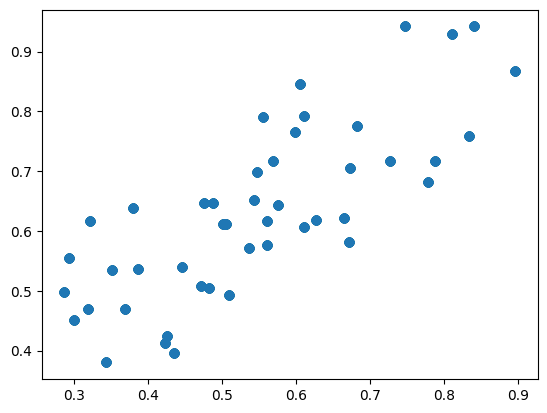

In [6]:
plt.plot(ds2_full["Mg [wt.%]"], ds2_full["Si [wt.%]"], 'o', alpha=0.5)